# Milestone 3: Initial Results and Coding

**Project:** Transportation Sustainability and Vehicle Emissions Prediction  
**Objective:** This notebook shows the proof-of-concept pipeline for predicting vehicle CO₂ emissions using the Canadian Fuel Consumption Ratings dataset. The notebook covers data loading, descriptive analysis, preprocessing, baseline modelling, model comparison, validation checks, and initial interpretation.

## 1. Import Libraries

This code imports the main Python libraries used in the notebook. Pandas and NumPy are used for data handling, Matplotlib and Seaborn are used for visualization, and scikit-learn is used for splitting the data, preprocessing, training models, and calculating regression metrics.

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



## 2. Data Loading and Initial Verification

In [ ]:
# Load dataset
df = pd.read_csv("/content/my2015-2024-fuel-consumption-ratings.csv")
# Display first five rows
df.head()

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
0,2015,Acura,ILX,Compact,2.0,4,AS5,Z,9.7,6.7,8.3,34,191,NaN,NaN
1,2015,Acura,ILX,Compact,2.4,4,M6,Z,10.8,7.4,9.3,30,214,NaN,NaN
2,2015,Acura,ILX Hybrid,Compact,1.5,4,AV7,Z,6.0,6.1,6.1,46,140,NaN,NaN
3,2015,Acura,MDX SH-AWD,Sport utility vehicle: Small,3.5,6,AS6,Z,12.7,9.1,11.1,25,255,NaN,NaN
4,2015,Acura,RDX AWD,Sport utility vehicle: Small,3.5,6,AS6,Z,12.1,8.7,10.6,27,244,NaN,NaN


In [ ]:
# Dataset dimensions
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(10060, 15)


In [ ]:
# Display columns
print(df.columns.tolist())

['Model year', 'Make', 'Model', 'Vehicle class', 'Engine size (L)', 'Cylinders', 'Transmission', 'Fuel type', 'City (L/100 km)', 'Highway (L/100 km)', 'Combined (L/100 km)', 'Combined (mpg)', 'CO2 emissions (g/km)', 'CO2 rating', 'Smog rating']


### Initial Verification

The dataset was successfully loaded into the Python environment. It contains approximately 10,060 observations and 15 variables describing vehicle specifications, fuel consumption measures, and environmental performance indicators for Canadian light-duty vehicles between 2015 and 2024.

## 3. Descriptive Statistics

In [ ]:
numerical_columns = df.select_dtypes(include=np.number)
descriptive_stats = pd.DataFrame({
    "Mean": numerical_columns.mean(),
    "Median": numerical_columns.median(),
    "Mode": numerical_columns.mode().iloc[0],
    "Variance": numerical_columns.var()})
print("Descriptive Statistics:")
print(descriptive_stats)

Descriptive Statistics:
                             Mean  Median    Mode     Variance
Model year            2019.242048  2019.0  2015.0     8.032172
Engine size (L)          3.144901     3.0     2.0     1.795627
Cylinders                5.618390     6.0     4.0     3.519037
City (L/100 km)         12.483012    12.1    10.8    11.590576
Highway (L/100 km)       9.142744     8.9     7.8     4.746595
Combined (L/100 km)     10.979672    10.7     9.4     7.887565
Combined (mpg)          27.436282    26.0    25.0    53.527802
CO2 emissions (g/km)   253.710338   250.0   242.0  3657.249421
CO2 rating               4.617443     5.0     5.0     2.479879
Smog rating              4.816509     5.0     5.0     3.181918


The descriptive statistics show that the dataset has enough variation for predictive modelling. CO₂ emissions and fuel consumption variables have larger spread than the rating variables, which means vehicles differ noticeably in environmental performance. This variation is useful because the model needs differences in the predictors to learn how vehicle characteristics relate to emissions.


## 4. Visual Analysis: Distributions, Patterns, and Outliers

The following histograms and boxplots are used to identify patterns, skewness, and possible outliers. This satisfies the Milestone 3 requirement to go beyond listing columns and characterize the dataset using visual evidence.

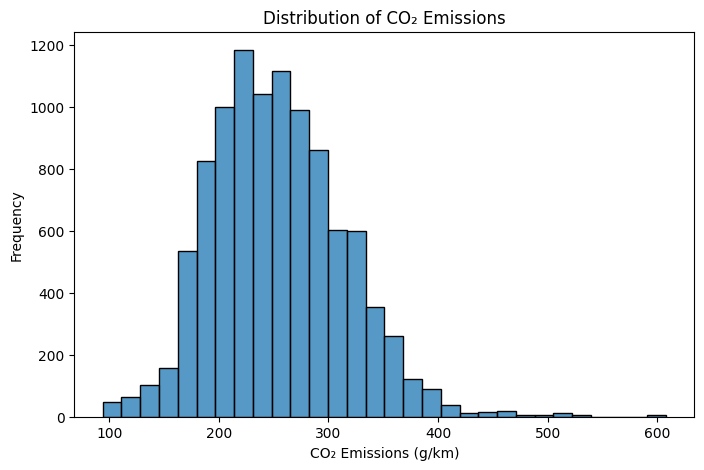

In [ ]:
# Create a histogram to examine the distribution of CO2 emissions
plt.figure(figsize=(8,5))
sns.histplot(df['CO2 emissions (g/km)'], bins=30)
plt.title('Distribution of CO₂ Emissions')
plt.xlabel('CO₂ Emissions (g/km)')
plt.ylabel('Frequency')
plt.show()

The histogram shows that CO₂ emissions vary across the vehicles included in the dataset. This variation indicates that the target variable contains a broad range of values, making it suitable for developing and evaluating regression models.

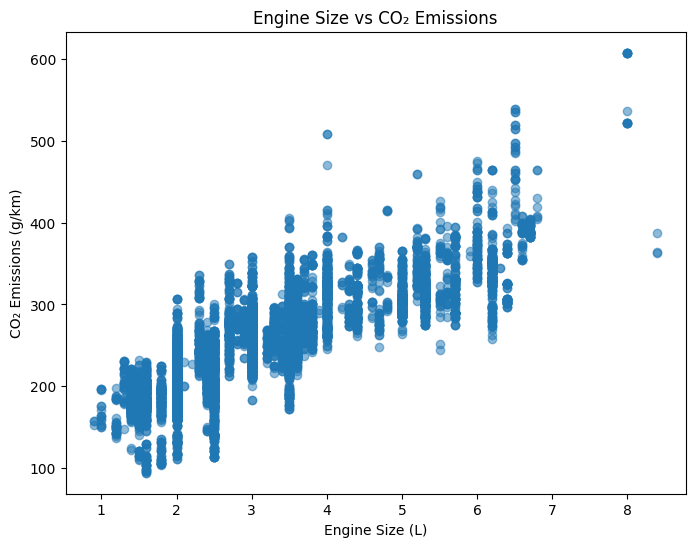

In [ ]:
# Scatter Plot: Engine Size vs CO₂ Emissions
plt.figure(figsize=(8,6))
plt.scatter(df['Engine size (L)'], df['CO2 emissions (g/km)'], alpha=0.5)
plt.title('Engine Size vs CO₂ Emissions')
plt.xlabel('Engine Size (L)')
plt.ylabel('CO₂ Emissions (g/km)')
plt.show()

The scatter plot shows a positive relationship between engine size and CO₂ emissions. Vehicles with larger engine sizes generally produce higher CO₂ emissions, although some variation exists among vehicles with similar engine sizes. This indicates that engine size is an important predictor and was retained for model development.

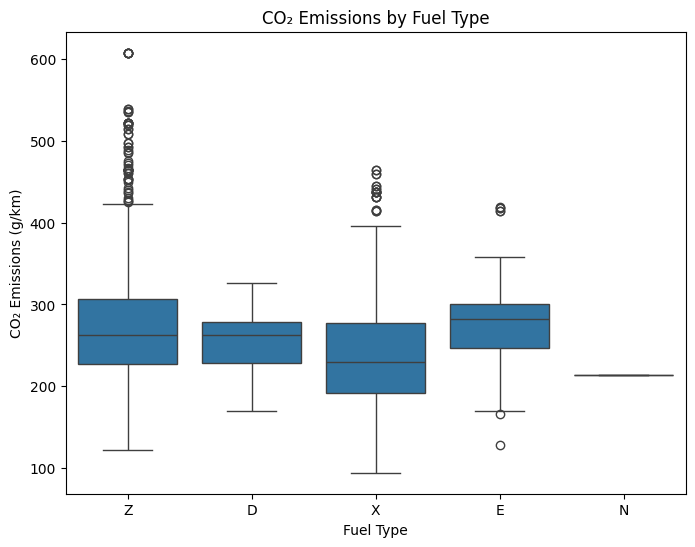

In [ ]:
# Create the boxplot to identify potential outliers
plt.figure(figsize=(8,6))
sns.boxplot(x='Fuel type', y='CO2 emissions (g/km)', data=df)
plt.title('CO₂ Emissions by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('CO₂ Emissions (g/km)')
plt.show() # Display the boxplot

The boxplot shows differences in CO₂ emissions across the various fuel types. These differences indicate that fuel type influences vehicle emissions and should be retained as a predictor variable during model development.

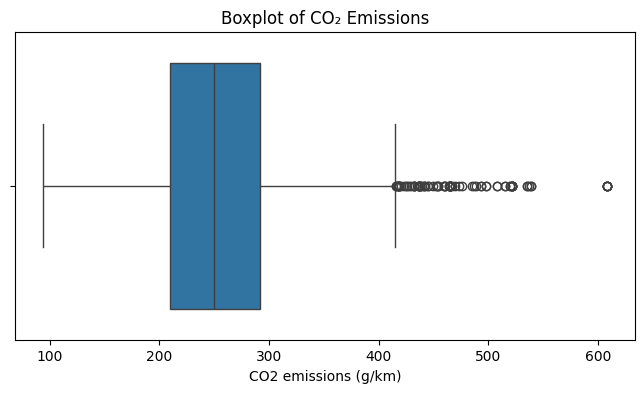

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['CO2 emissions (g/km)'])
plt.title('Boxplot of CO₂ Emissions')
plt.show()

The boxplot identifies several high-emission observations within the dataset. These values were retained because they represent genuine vehicle records and provide useful information for training the prediction models.

## Unusual Patterns, Trends, and Outliers**

The visual analysis showed that CO₂ emissions, fuel consumption, and engine size are moderately right-skewed. Most vehicles have lower to moderate values, while a smaller number have much higher values.

Boxplots identified several outliers, particularly for CO₂ emissions, fuel consumption, and engine size. These observations represent valid high-performance vehicles rather than data errors.

Therefore, the outliers were retained to preserve the full range of vehicle characteristics. However, their presence may influence model performance, making it important to compare Multiple Linear Regression and Random Forest Regression.

## 5. Data Preprocessing and Transformation
This section prepares the data for machine learning. The workflow follows the required leakage-safe order: define features and target, split the data into training and testing sets, then apply imputation, encoding, and scaling using the training data only. This order is important because the test set must remain unseen until final evaluation.

### 5.1 Feature and Target Selection

In [ ]:
# Define target variable
target = df['CO2 emissions (g/km)']

# Define feature variables
features = df.drop(columns=['CO2 emissions (g/km)'])

print("Features shape:", features.shape)
print("Target shape:", target.shape)

Features shape: (10060, 14)
Target shape: (10060,)


This output confirms that the predictors and target were separated correctly.

### 5.2 Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split
# Split data before preprocessing
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.20, random_state=42)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8048, 14)
Testing data: (2012, 14)


The output shows the number of records in the training and testing datasets. The training data is used to fit preprocessing steps and train the models. The testing data is kept aside and used only for final model evaluation.

### 5.3 Missing Value Treatment

This code first checks missing values in the training data. Then numerical missing values are imputed using the median from the training set only. Median imputation is suitable here because CO₂ Rating and Smog Rating are rating-scale variables, and the median is less affected by extreme values than the mean.

In [ ]:
# Check missing values in training data
X_train.isnull().sum()

,0
Model year,0
Make,0
Model,0
Vehicle class,0
Engine size (L),0
Cylinders,0
Transmission,0
Fuel type,0
City (L/100 km),0
Highway (L/100 km),0


In [ ]:
# Select numerical columns
numeric_columns = X_train.select_dtypes(include=['int64', 'float64']).columns

# Fill missing values using training median
for col in numeric_columns:
    median_value = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

# Check remaining missing values
print("Missing values in training data:", X_train.isnull().sum().sum())
print("Missing values in testing data:", X_test.isnull().sum().sum())

Missing values in training data: 0
Missing values in testing data: 0


Missing numerical values were filled using the median calculated from the training data. Median imputation was selected because it is less affected by extreme values.

### 5.4 Categorical Encoding

In [ ]:
# Convert categorical variables into dummy variables
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies( X_test, drop_first=True)

# Match training and testing columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("Training data after encoding:", X_train.shape)

print("Testing data after encoding:", X_test.shape)



Training data after encoding: (8048, 2059)
Testing data after encoding: (2012, 2059)


Categorical variables were converted using one-hot encoding. This was used instead of label encoding because categories such as make, model, vehicle class, transmission, and fuel type do not have a natural order.

### 5.5 Numerical Scaling

StandardScaler is applied to numerical variables after the train-test split. The scaler is fitted on the training data and then applied to the test data. This prevents data leakage and makes numerical variables with different units more comparable during model training.

In [ ]:
from sklearn.preprocessing import StandardScaler
# Standardize numerical variables
scaler = StandardScaler()

X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

# Display scaled values
X_train[numeric_columns].head()

,Model year,Engine size (L),Cylinders,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 rating,Smog rating
8014,0.967425,-0.112870,0.197787,0.261863,0.110328,0.213136,-0.463667,-0.436490,-1.185639
8318,0.967425,0.186628,0.197787,0.349728,0.751988,0.497306,-0.600692,-0.436490,0.089180
1544,-1.147430,-1.235987,-0.868383,-0.763228,-1.218824,-0.923543,0.906580,1.580469,0.089180
8290,0.967425,-0.861614,-0.868383,-1.466148,-1.493821,-1.491882,2.002778,1.580469,1.364000
1718,-1.147430,-0.562117,-0.868383,-0.470345,-0.668830,-0.532809,0.358481,0.908149,0.089180


Standardization was applied to numerical variables because the variables are measured on different scales. The scaler was fitted on the training data and then applied to the testing data.

### 5.6 Final Preprocessing Check

In [ ]:
print("Final training data shape:", X_train.shape)
print("Final testing data shape:", X_test.shape)

print("Missing values in training data:", X_train.isnull().sum().sum())
print("Missing values in testing data:", X_test.isnull().sum().sum())

Final training data shape: (8048, 2058)
Final testing data shape: (2012, 2058)
Missing values in training data: 0
Missing values in testing data: 0


At this stage, the dataset is ready for model development.

## 6. Model Development and Evaluation


In [ ]:
from sklearn.linear_model import LinearRegression

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

LinearRegression()

The trained model is then used to predict CO₂ emissions for the testing dataset. The first few predictions are printed to show that the model is producing output.


In [ ]:
# Predict on testing data
y_pred = lr_model.predict(X_test)

# Display first few predictions
print(y_pred[:5])

[181.69802827 227.89056187 243.74641275 213.52331389 196.78218551]


### 6.2 Baseline Model Metrics

The model is evaluated using MAE, RMSE, and R². These metrics are selected because this is a regression problem. MAE and RMSE measure prediction error in g/km, while R² shows how much variation in CO₂ emissions is explained by the model.

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np # Import numpy for square root function

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error( y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2.216198465045575
RMSE: 3.5353177899240436
R2 Score: 0.9964885967350564


### 6.3 Actual vs Predicted Plot for Baseline Model

This scatter plot compares actual CO₂ emissions with predicted CO₂ emissions. A strong model should place most points close to a diagonal pattern, meaning predicted values are close to the true values.


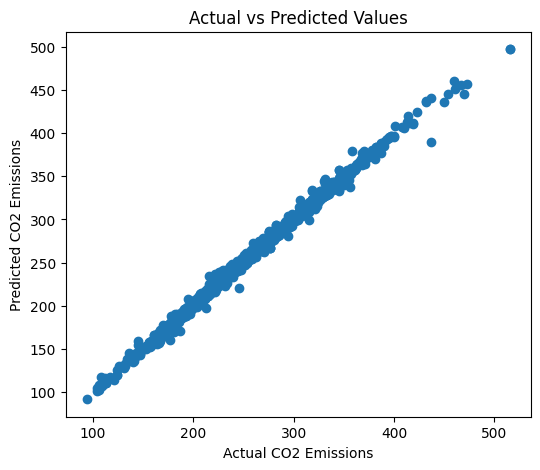

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual CO2 Emissions")
plt.ylabel("Predicted CO2 Emissions")

plt.title("Actual vs Predicted Values")
plt.show()

The plot provides visual evidence that the baseline model is producing interpretable results. Points close to the diagonal trend show that the model predicts most observations accurately, while points farther away represent larger prediction errors.

## 7. Proxy Leakage Assessment

Fuel consumption variables and environmental ratings are closely related to CO₂ emissions. To check whether the model is relying too strongly on these proxy variables, this comparison removes fuel consumption measures and CO₂ rating from the feature set and re-runs the Linear Regression model. This helps address the feedback about proxy leakage or circular prediction.

In [ ]:
# Checking Leakage. Create a copy of original dataset
df_compare = df.copy()

# Define target variable
target = df_compare['CO2 emissions (g/km)']

# Remove target and possible proxy variables
features = df_compare.drop(columns=[
    'CO2 emissions (g/km)',
    'CO2 rating',
    'City (L/100 km)',
    'Highway (L/100 km)',
    'Combined (L/100 km)',
    'Combined (mpg)'])

# Split data
from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(features, target, test_size=0.20, random_state=42)

# Fill missing numerical values
numeric_columns = X_train2.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    median_value = X_train2[col].median()
    X_train2[col] = X_train2[col].fillna(median_value)
    X_test2[col] = X_test2[col].fillna(median_value)

# Convert categorical variables
X_train2 = pd.get_dummies(X_train2, drop_first=True)
X_test2 = pd.get_dummies(X_test2, drop_first=True)

X_train2, X_test2 = X_train2.align(X_test2,join='left',axis=1,fill_value=0)

# Scale numerical variables
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train2[numeric_columns] = scaler.fit_transform(X_train2[numeric_columns])

X_test2[numeric_columns] = scaler.transform(X_test2[numeric_columns])

# Train Linear Regression
from sklearn.linear_model import LinearRegression

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

# Predictions
y_pred2 = model2.predict(X_test2)

# Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae2 = mean_absolute_error(y_test2, y_pred2)
mse2 = mean_squared_error(y_test2, y_pred2)
rmse2 = np.sqrt(mse2)
r22 = r2_score(y_test2, y_pred2)

print("MAE:", mae2)
print("RMSE:", rmse2)
print("R2 Score:", r22)

MAE: 8.940685641133397
RMSE: 13.849482062083421
R2 Score: 0.9461121501296555


If performance drops after removing proxy variables, it means those variables contain strong predictive information. However, if the model still performs reasonably well, it shows that vehicle specifications such as engine size, cylinders, transmission, fuel type, and vehicle class also help explain emissions. This check strengthens the validation of the modelling approach.

**Linear Regression Assumption Test**

In [ ]:
# Calculate residuals
residuals = y_test - y_pred
residuals.head()

,CO2 emissions (g/km)
8294,0.301972
3131,0.109438
2777,2.253587
9305,1.476686
107,-3.782186


Residuals are calculated as actual values minus predicted values. Residual analysis helps identify whether the model is making systematic errors.

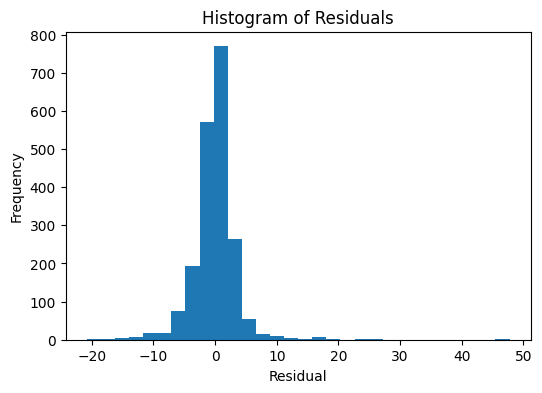

In [ ]:
plt.figure(figsize=(6,4))

plt.hist(residuals, bins=30)

plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

The residual histogram shows whether prediction errors are centered around zero. A concentration near zero suggests that most errors are small.

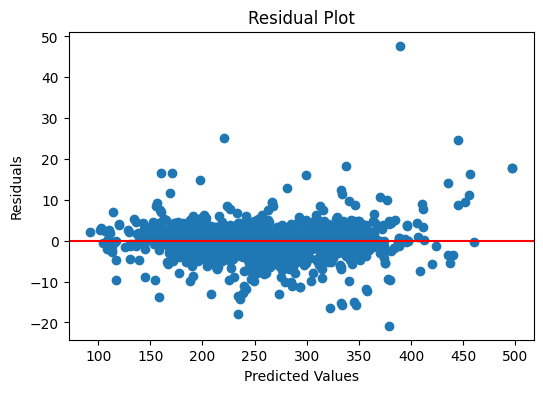

In [ ]:
plt.figure(figsize=(6,4))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red')

plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()

The residual plot checks whether errors are randomly scattered around zero. A random pattern suggests that the model has captured the main relationship between predictors and CO₂ emissions.


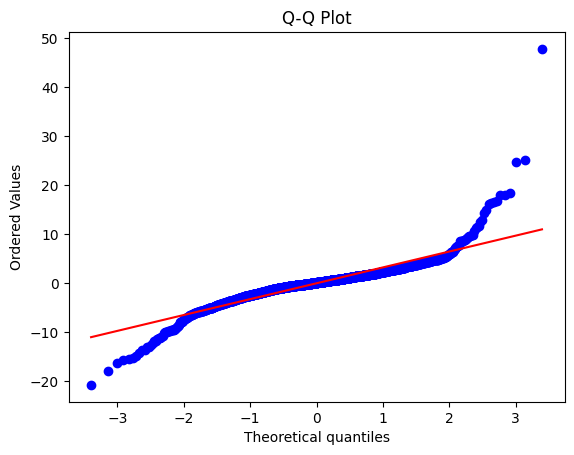

In [ ]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")

plt.show()

The Q-Q plot checks whether residuals are approximately normally distributed. Minor deviations at the ends are expected, but a mostly straight pattern supports the baseline model as a reasonable starting point.


## 9. Comparison Model: Random Forest Regression

Random Forest Regression is developed as a second model to compare with the baseline. This model is useful because it can capture non-linear relationships and interactions between vehicle variables without assuming a straight-line relationship.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train model
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

The Random Forest model is trained using the same processed training dataset as Linear Regression. Using the same train-test split makes the model comparison fair.


In [ ]:
# Predict on test data
rf_predictions = rf_model.predict(X_test)

print(rf_predictions[:5])

[182.27 228.89 246.39 215.65 193.  ]


### 9.1 Random Forest Metrics

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np # Import numpy for square root function

rf_mae = mean_absolute_error(y_test, rf_predictions)

# Calculate MSE first, then take the square root for RMSE
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

MAE: 1.0235089463220672
RMSE: 3.22856648540739
R2 Score: 0.9970715132747772


### 9.2 Overfitting Check

In [ ]:
# Training score
train_score = rf_model.score(X_train, y_train)

# Testing score
test_score = rf_model.score(X_test, y_test)

print("Training R2:", train_score)
print("Testing R2:", test_score)

Training R2: 0.999401408712183
Testing R2: 0.9970715132747772


Overfitting Assessment: An overfitting assessment was performed to determine whether the Random Forest model generalized well to unseen data. This was done by comparing the model's performance on the training and testing datasets.

##**Overall Summary**

In this notebook, the dataset was successfully prepared for machine learning by handling missing values, encoding categorical variables, scaling numerical features, and splitting the data into training and testing sets.

Two regression models, Multiple Linear Regression and Random Forest Regression, were developed and evaluated using MAE, RMSE, and R². Both models produced strong results, while Random Forest Regression achieved slightly better prediction performance.

Additional validation checks, including overfitting and proxy leakage assessment, were also completed to evaluate the reliability of the models. The results suggest that the modelling pipeline is working as expected and provides a good starting point for the final stage of the project.